# Manufacturing Inspection
In this assignment you will apply simple image processing techniques to determine the level of liquid in a bottle.
This simple approach allows us to identify overfilled bottles on a production line.

![link text](https://github.com/draziraphale/PD_CV/blob/main/Section%201/manu_inspect.jfif?raw=true?raw=true)



Before beginning this exercise you should think about and engage with your peers (on the forum) about the likely sequence of steps necessary to complete the exercise. As you make progress you can discuss what approaches are working well or are failing. Some useful information is provided below. Much of the necessary code can be found in the example notebooks provided.

*   [OpenCV2 Threshold](https://docs.opencv.org/4.5.1/d7/d4d/tutorial_py_thresholding.html) (example of use here)
*   [OpenCV2 Morphology Operations](https://docs.opencv.org/4.5.2/d9/d61/tutorial_py_morphological_ops.htmlf) (example of use here)
*   [Canny Algorithm](https://docs.opencv.org/3.4/da/d22/tutorial_py_canny.html) (example of use)
*   [Hough Algorithm](https://docs.opencv.org/3.4/d9/db0/tutorial_hough_lines.html) (example of use)





# Housekeeping:
Import packages, read test image, define helper functions.

In [47]:
import numpy as np
from skimage import feature
from scipy import signal
import cv2
import matplotlib.pyplot as plt
import urllib.request


In [48]:
# function to read images from Web addresses.
def url_to_image(url):
	resp = urllib.request.urlopen(url)
	temp_image = np.asarray(bytearray(resp.read()), dtype="uint8")
	temp_image = cv2.imdecode(temp_image, cv2.IMREAD_COLOR)
	temp_image = cv2.cvtColor(temp_image, cv2.COLOR_BGR2RGB) # OpenCV defaults to BGR, but we need RGB
	return temp_image

A Mask for the Region of Interest containing specific edges from the image can be created using the cv2.fillPoly command that can create a a filled region, the number of sides of the region is determined by the number of vertices applied. If a rectangle is required then 4 vertices are needed.

In [49]:
"""
# In order to create a rectangular mask 4 points are needed
# These are arranged clockwise (starting at any corner of the rectangle).
# NB Coordinates are given in the form (width,height) with the origin in the top left

e.g.
l1 = [50,150]
l2 = [50,20]
r1 = [400,20]
r2 = [400,150]

# The coodinates are converted to an array that is given to the mask function
# along with the input image, both the mask and masked image are returned.
vertices = np.array([[l1,l2,r1,r2 ]], dtype=np.int32)
"""
#Mask region of Interest.
def mask_img(image,vertices):
    #Create mask
    mask = np.zeros_like(image)
    #Add white to region of interest
    cv2.fillPoly(mask, vertices, 255)
    # apply mask to image
    masked_image = cv2.bitwise_and(image,image, mask=mask)
    return mask,masked_image

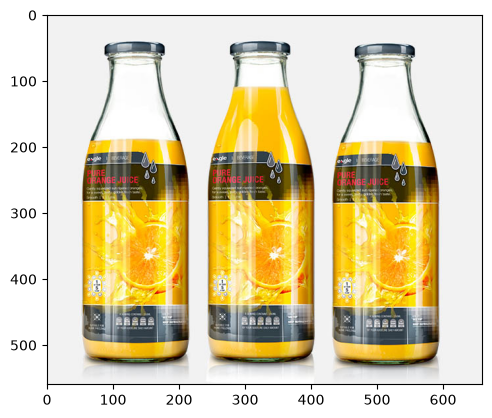

In [50]:
# read in test image
image_url = "https://cdn.eaglepi.com/uploads/2016/08/NEW_Fill_level_Rounded_Image_660pxh.jpg"

image = url_to_image(image_url)
plt.imshow(image)


# Method

The detection pipeline uses grayscale conversion, Gaussian blur, Canny edges, bottle masks, closing, and Hough line selection. The selected levels are compared with a fixed acceptance band for this image. A separate threshold and opening comparison follows the final result.


# Preprocessing and bottle ROIs

The three rectangles serve as the bottle regions. Gaussian blur reduces small intensity variations, essentially 'smoothing' the harsher details in the image. 

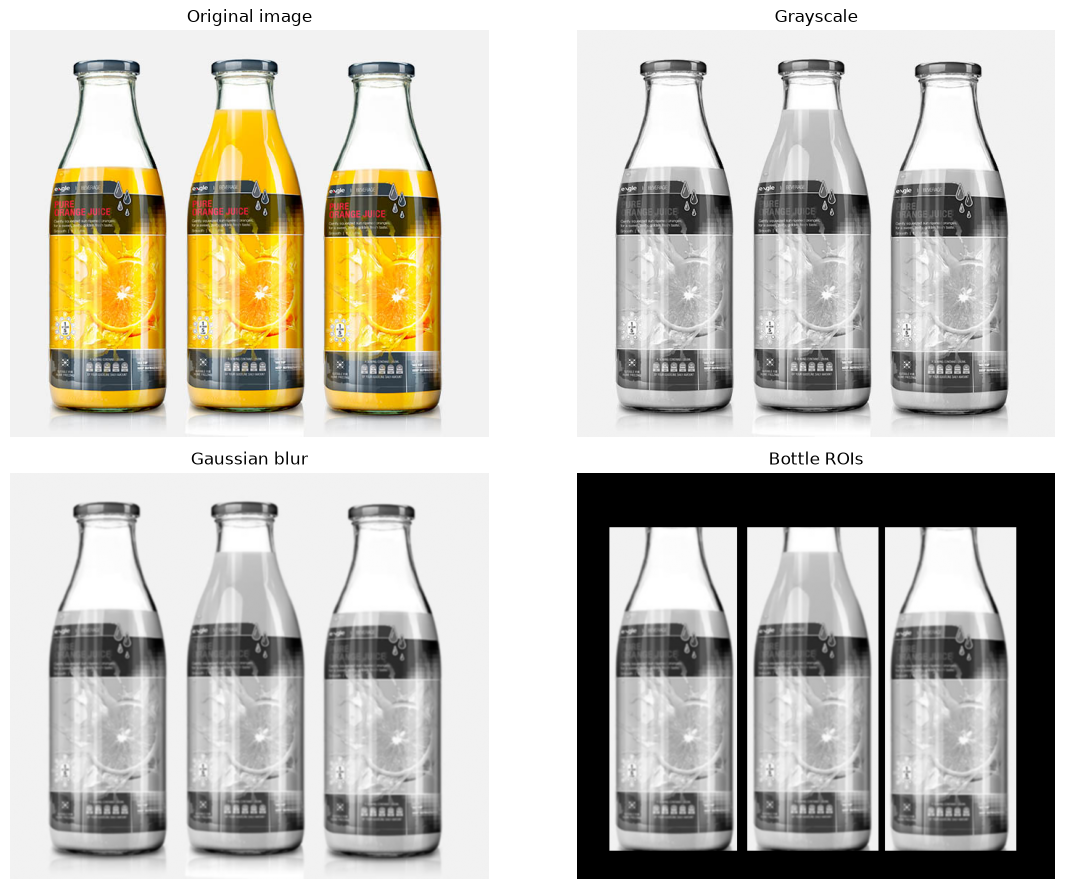

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

bottle_rois = [
    (45, 75, 220, 520),
    (235, 75, 415, 520),
    (425, 75, 605, 520),
]

# Create one mask and masked image for each bottle using the supplied function.
roi_mask = np.zeros_like(gray, dtype=np.uint8)
roi_image = np.zeros_like(blurred)
for x_min, y_min, x_max, y_max in bottle_rois:
    roi_vertices = np.array([[[x_min, y_min], [x_min, y_max],
                             [x_max, y_max], [x_max, y_min]]], dtype=np.int32)
    bottle_mask, bottle_image = mask_img(blurred, roi_vertices)
    roi_mask = cv2.bitwise_or(roi_mask, bottle_mask)
    roi_image = cv2.bitwise_or(roi_image, bottle_image)

# Preview the inputs and bottle regions.
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, preview, title in zip(axes.ravel(),
        [image, gray, blurred, roi_image],
        ['Original image', 'Grayscale', 'Gaussian blur', 'Bottle ROIs']):
    ax.imshow(preview, cmap='gray' if preview.ndim == 2 else None)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


# Edge detection and closing

Canny runs before masking to avoid artificial edges at the rectangle boundaries. Closing connects nearby edge fragments. The two plots show the masked edges before and after closing.


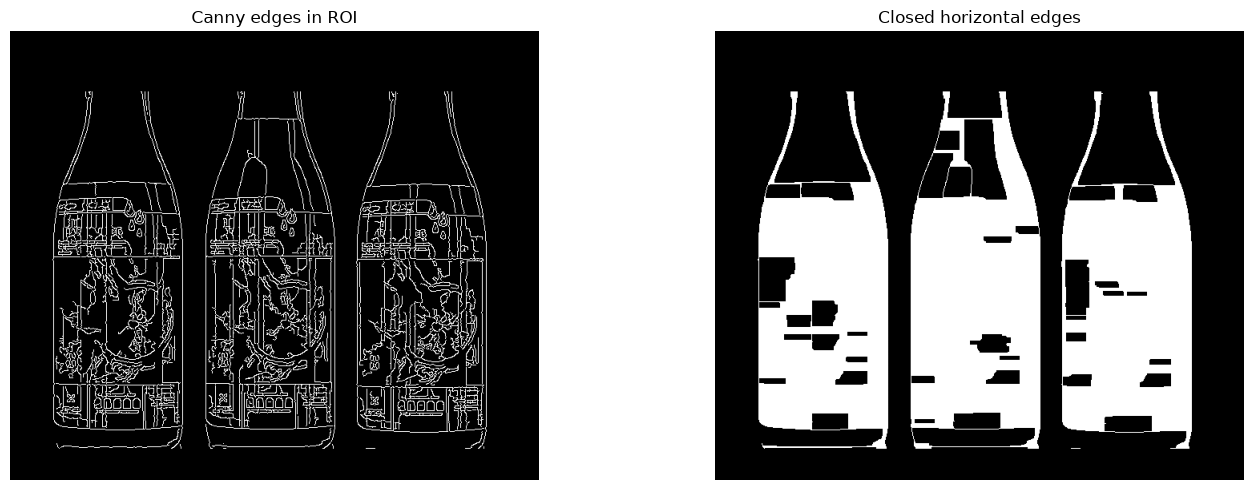

In [52]:
# Canny is applied before masking so that the ROI boundary itself doesn't create artificial edges.
low_threshold = 10
high_threshold = 130
edges = cv2.Canny(blurred, low_threshold, high_threshold)
edges = cv2.bitwise_and(edges, edges, mask=roi_mask)

# Connecting nearby fragments using a predominantly horizontal kernel.
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 5))
closed_edges = cv2.morphologyEx(
    edges, cv2.MORPH_CLOSE, horizontal_kernel, iterations=1
)

fig, axarr = plt.subplots(1, 2, figsize=(15, 5))
axarr[0].imshow(edges, cmap='gray')
axarr[0].set_title('Canny edges in ROI')
axarr[1].imshow(closed_edges, cmap='gray')
axarr[1].set_title('Closed horizontal edges')
for axis in axarr:
    axis.axis('off')
plt.tight_layout()

# Line detection and selection

Hough returns candidate segments. Angle and height filters are attempting to reject irrelevant lines, then the longest remaining segment is selected for each bottle. Its mean endpoint row estimates the horizontal liquid level. 

Red lines below show all accepted candidates.


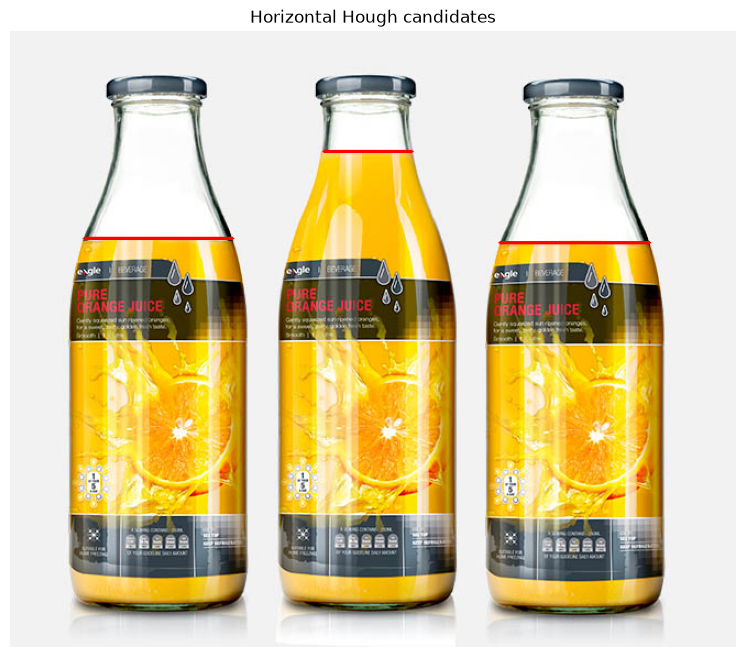

In [53]:
hough_lines = cv2.HoughLinesP(
    closed_edges,
    rho=1,
    theta=np.pi / 180,
    threshold=25,
    minLineLength=50,
    maxLineGap=25,
)

level_y_min, level_y_max = 90, 205
max_angle_degrees = 5
candidate_lines = []

if hough_lines is not None:
    for line in np.asarray(hough_lines).reshape(-1, 4):
        x1, y1, x2, y2 = [int(value) for value in line]
        dx, dy = x2 - x1, y2 - y1
        length = float(np.hypot(dx, dy))
        angle = abs(np.degrees(np.arctan2(dy, dx)))
        angle = min(angle, 180 - angle)
        midpoint_x = (x1 + x2) / 2
        midpoint_y = (y1 + y2) / 2

        if angle > max_angle_degrees:
            continue
        if not level_y_min <= midpoint_y <= level_y_max:
            continue

        for bottle_index, (x_min, y_min, x_max, y_max) in enumerate(bottle_rois):
            if x_min <= midpoint_x <= x_max:
                candidate_lines.append({
                    'bottle': bottle_index,
                    'line': (x1, y1, x2, y2),
                    'length': length,
                    'y': midpoint_y,
                })
                break

selected_lines = {}
for candidate in candidate_lines:
    bottle_index = candidate['bottle']
    if (bottle_index not in selected_lines or
            candidate['length'] > selected_lines[bottle_index]['length']):
        selected_lines[bottle_index] = candidate

line_image = image.copy()
for candidate in candidate_lines:
    x1, y1, x2, y2 = candidate['line']
    y = int(round(candidate['y']))
    cv2.line(line_image, (x1, y), (x2, y), (255, 0, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(line_image)
plt.title('Horizontal Hough candidates')
plt.axis('off')
plt.show()

# Classification and final result

For this fixed image, detected levels from row 140 to 205 inclusive pass. A smaller row indicates an overfill. A larger row indicates an underfill.

The detector searches only rows 90 to 205. Levels outside that range or hidden by the label may be missed but this is acceptable for this scenario. A bottle with no selected line is labelled CHECK, not automatically passed or declared underfilled.


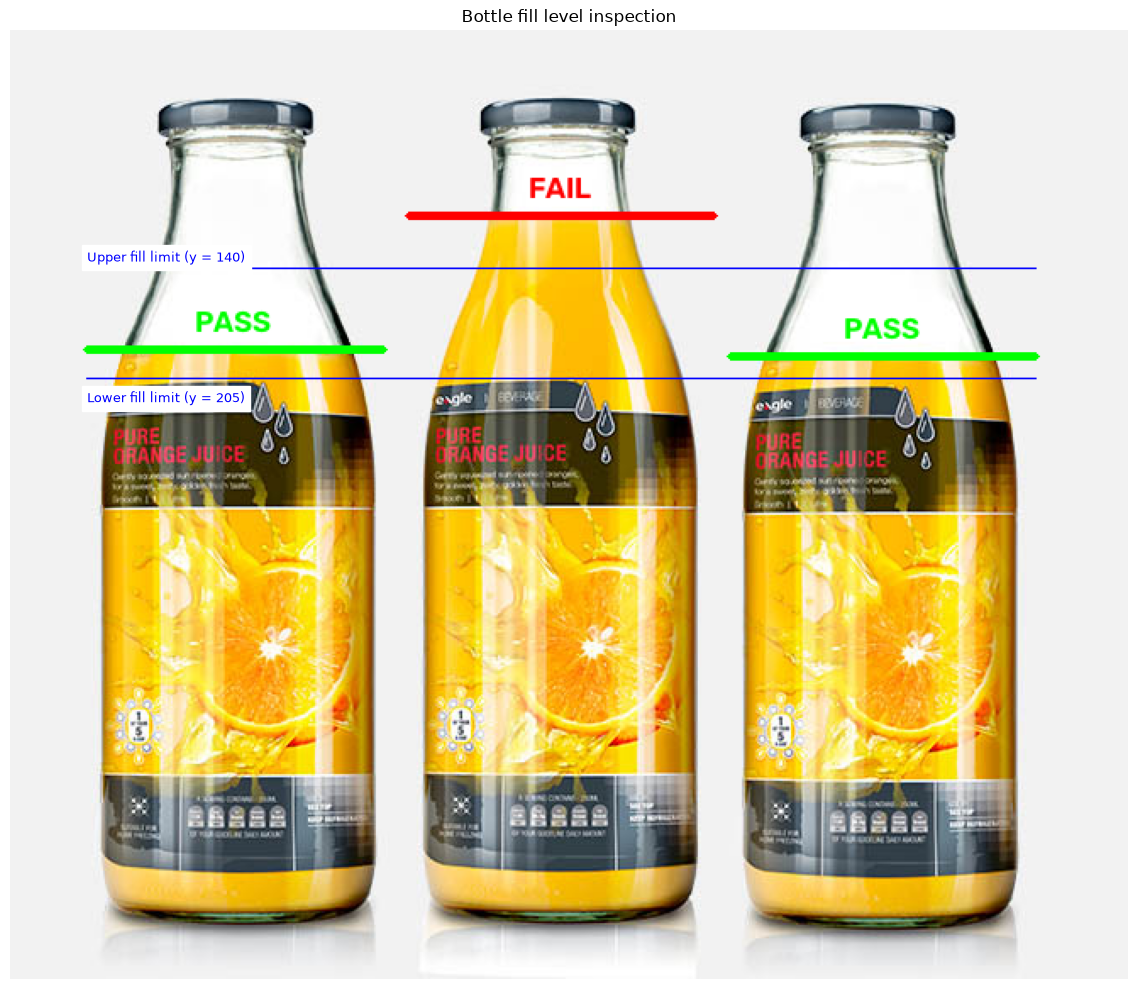

Bottle 1: PASS (y = 188.5)
Bottle 2: FAIL (y = 109.0)
Bottle 3: PASS (y = 191.5)


In [54]:
pass_level_min = 140
pass_level_max = 205
bottle_results = {i: 'CHECK' for i in range(len(bottle_rois))}
for bottle_index, candidate in selected_lines.items():
    status = (
        'PASS' if pass_level_min <= candidate['y'] <= pass_level_max
        else 'FAIL'
    )
    bottle_results[bottle_index] = status

out = image.copy()
display_x_min = min(roi[0] for roi in bottle_rois)
display_x_max = max(roi[2] for roi in bottle_rois)
cv2.line(out, (display_x_min, pass_level_min),
         (display_x_max, pass_level_min), (0, 0, 255), 1)
cv2.line(out, (display_x_min, pass_level_max),
         (display_x_max, pass_level_max), (0, 0, 255), 1)

for bottle_index, candidate in selected_lines.items():
    x_min, y_min, x_max, y_max = bottle_rois[bottle_index]
    y = int(round(candidate['y']))
    status = bottle_results[bottle_index]
    colour = (0, 255, 0) if status == 'PASS' else (255, 0, 0)

    cv2.line(out, (x_min, y), (x_max, y), colour, 3)
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.6
    thickness = 2
    (text_width, text_height), _ = cv2.getTextSize(
        status, font, font_scale, thickness
    )
    text_x = (x_min + x_max - text_width) // 2
    text_y = y - 10
    cv2.putText(
        out, status, (text_x, text_y), font, font_scale,
        colour, thickness, cv2.LINE_AA
    )

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(out)
ax.text(display_x_min, pass_level_min - 4, 'Upper fill limit (y = 140)',
        color='blue', fontsize=9, backgroundcolor='white')
ax.text(display_x_min, pass_level_max + 14, 'Lower fill limit (y = 205)',
        color='blue', fontsize=9, backgroundcolor='white')
for bottle_index, (x_min, y_min, x_max, y_max) in enumerate(bottle_rois):
    if bottle_results[bottle_index] == 'CHECK':
        ax.text((x_min + x_max) / 2, 160, 'CHECK', ha='center',
                color='darkorange', weight='bold', backgroundcolor='white')
ax.set_title('Bottle fill level inspection')
ax.axis('off')
plt.tight_layout()
plt.show()

for bottle_index, status in bottle_results.items():
    candidate = selected_lines.get(bottle_index)
    level = f"y = {candidate['y']:.1f}" if candidate else 'no level detected'
    print(f'Bottle {bottle_index + 1}: {status} ({level})')


# Other experiments
Here are some other things I tried as experiments to see what results I could get.
This experiment applies TOZERO thresholding and opening to the ROI preview.


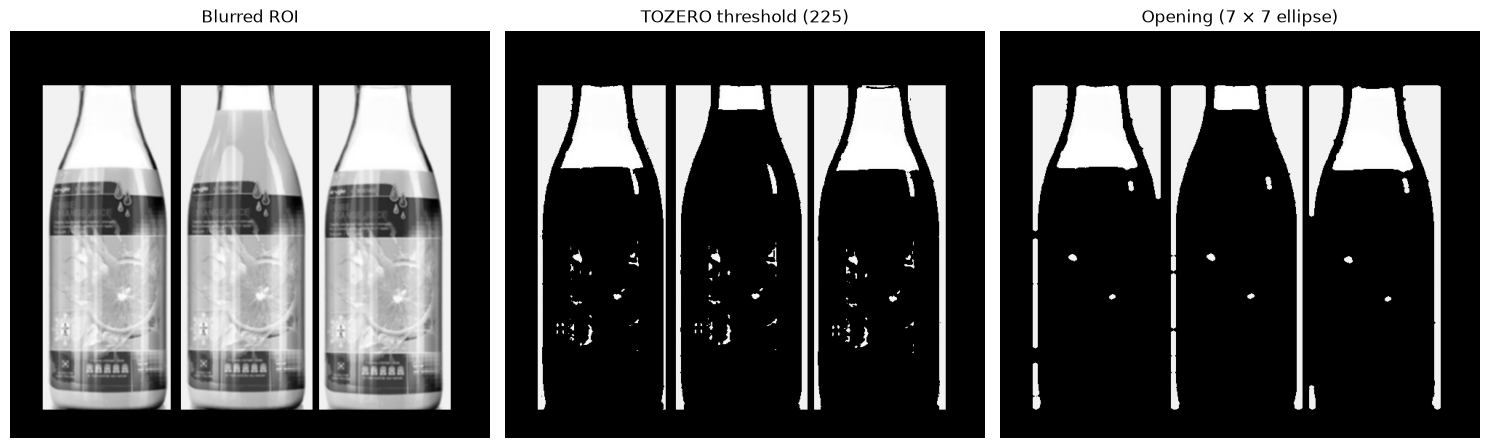

In [55]:
threshold_value = 240
_, thresholded_roi = cv2.threshold(
    roi_image, threshold_value, 255, cv2.THRESH_TOZERO
)
opening_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
opened_roi = cv2.morphologyEx(
    thresholded_roi, cv2.MORPH_OPEN, opening_kernel, iterations=1
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, preview, title in zip(axes,
        [roi_image, thresholded_roi, opened_roi],
        ['Blurred ROI', 'TOZERO threshold (225)', 'Opening (7 × 7 ellipse)']):
    ax.imshow(preview, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


# Reflection

The main challenge was separating the liquid surface from the labels, bottle sides and reflections. The lane identification example provided a useful starting point, but detecting edges alone was not enough. I used three bottle ROIs and a separate height band to assign lines to each bottle and reject irrelevant candidates. These fixed regions suit this image but would need adjustment if the camera or bottles moved e.g. in a production environment.

I applied a 5 × 5 Gaussian blur, followed by Canny on the full image before masking the edges. A 25 × 5 closing kernel then connects nearby edge fragments, although increasing its size too much could merge unrelated edges.

After Hough detection, I retain lines within five degrees of horizontal and rows 90 to 205, then select the longest candidate per bottle. Length provides a simple measure of support, while choosing the highest line could select an unrelated edge. Neither rule is sufficient on its own, which is why I combine these constraints.

For display, I average the selected segment's endpoint rows and draw a horizontal line across the bottle ROI. As Matthew pointed out while reviewing my work, this reflects the assumption of a stationary liquid surface in an aligned image.

I had a look at Joseph Connolly's work and found it very interesting, and so it inspired the TOZERO and opening experiment. I used a threshold of 240 and a 7 × 7 elliptical opening kernel to explore the effect on bright features. These outputs are not used by the final Canny pipeline, but i found the approach very interesting and effective.

The fixed acceptance band of rows 140 to 205 gives the intended result: the middle bottle fails and the other two pass. I chose a fixed reference because comparing bottles only identifies differences, not the correct 'fill level'. As such, these limits are specific to the assignment image. Since the search also ends at row 205, the method cannot confirm underfill below that boundary, which in this case is around the label. Missing detections are marked CHECK, while this was not required, I chose to keep it as I am used to providing these fallback cases through my work in production inspection systems.

The main lesson was to inspect each processing stage and make the assumptions behind the final result clear. Testing different lighting and bottle positions, automatically locating the ROIs, and comparing against Sobel Y or contour detection would be useful next steps. Thanks again to Matthew for his feedback on masking and horizontal alignment, and Joseph for the inspiration behind the thresholding comparison.
